In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/processed/btc_1sec_core.csv")
df["system_time"] = pd.to_datetime(df["system_time"])
df = df.sort_values("system_time").reset_index(drop=True)

df.head()


,system_time,midpoint,spread,buys,sells
0,2021-04-07 12:32:42.122161+01:00,56035.995,0.01,0.0,0.0
1,2021-04-07 12:32:43.122161+01:00,56035.995,0.01,0.0,0.0
2,2021-04-07 12:32:44.122161+01:00,56035.995,0.01,0.0,0.0
3,2021-04-07 12:32:45.122161+01:00,56035.995,0.01,0.0,0.0
4,2021-04-07 12:32:46.122161+01:00,56035.995,0.01,0.0,0.0


In [2]:
mid = df["midpoint"].to_numpy(dtype=float)
spr = df["spread"].to_numpy(dtype=float)

# For market order fill model (baseline): buy crosses ask, sell crosses bid
ask = mid + 0.5 * spr
bid = mid - 0.5 * spr

n = len(df)
n


1030728

In [3]:
def simulate_twap_episodes(mid, bid, ask, Q=1.0, N=300, side="buy",
                           n_episodes=2000, rng_seed=42):
    """
    Returns:
      start_idx: (n_episodes,)
      avg_px:    (n_episodes,) average execution price
      is_bps:    (n_episodes,) implementation shortfall in bps (signed, buy positive cost)
      is_usd:    (n_episodes,) implementation shortfall in $ (signed)
    """
    rng = np.random.default_rng(rng_seed)
    n = len(mid)
    assert N > 1 and N < n, "Bad horizon N"

    # choose valid random start indices so the window [s, s+N) fits
    start_idx = rng.integers(0, n - N, size=n_episodes)

    # pick the execution price series for each episode
    if side.lower() == "buy":
        px_series = ask
        sign = +1.0
    elif side.lower() == "sell":
        px_series = bid
        sign = -1.0
    else:
        raise ValueError("side must be 'buy' or 'sell'")

    q = Q / N

    avg_px = np.empty(n_episodes)
    arrival = np.empty(n_episodes)

    for i, s in enumerate(start_idx):
        arrival[i] = mid[s]                       # decision / arrival price
        window_px = px_series[s:s+N]              # N seconds TWAP fills
        avg_px[i] = window_px.mean()              # equal-sized slices => mean

    # Implementation shortfall (per-unit): sign*(avg_exec - arrival)
    is_per_unit = sign * (avg_px - arrival)

    # Convert to $ and bps
    is_usd = is_per_unit * Q
    is_bps = (is_per_unit / arrival) * 1e4

    return start_idx, avg_px, is_bps, is_usd


In [4]:
start_idx, avg_px, is_bps, is_usd = simulate_twap_episodes(
    mid=mid, bid=bid, ask=ask,
    Q=1.0, N=300, side="buy",
    n_episodes=2000, rng_seed=7
)

pd.Series(is_bps).describe(percentiles=[0.5, 0.9, 0.95, 0.99])


count    2000.000000
mean       -0.015005
std        13.299440
min      -292.031090
50%        -0.094238
90%        12.528329
95%        17.926688
99%        32.994881
max        99.818860
dtype: float64

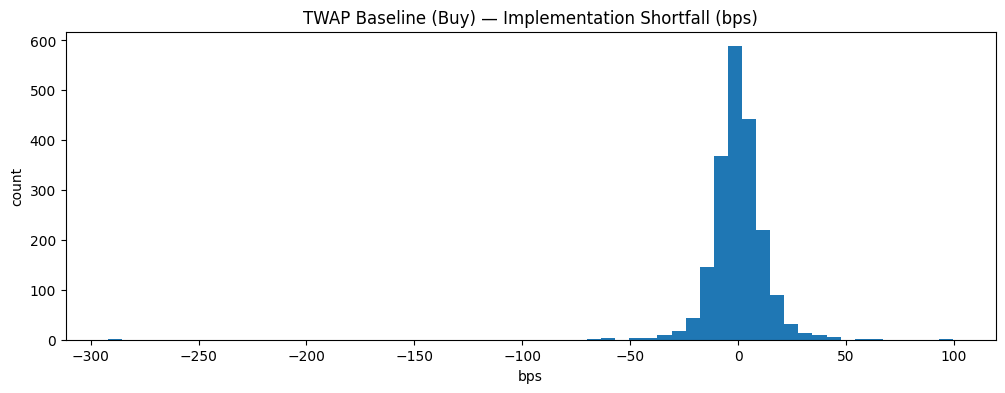

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.hist(is_bps, bins=60)
plt.title("TWAP Baseline (Buy) — Implementation Shortfall (bps)")
plt.xlabel("bps")
plt.ylabel("count")
plt.show()


In [7]:
# Recompute features needed for regimes
df["ret_1s"] = df["midpoint"].pct_change()
df["vol_60s"] = df["ret_1s"].rolling(60).std() * (60**0.5)

df["OFI"] = df["buys"] - df["sells"]
df["nOFI"] = df["OFI"] / (df["buys"] + df["sells"] + 1)


In [8]:
# Volatility regimes
df["vol_regime"] = pd.qcut(
    df["vol_60s"],
    q=3,
    labels=["Low Vol", "Medium Vol", "High Vol"]
)

# OFI regimes
df["ofi_regime"] = pd.cut(
    df["nOFI"],
    bins=[-1, -0.3, 0.3, 1],
    labels=["Sell Pressure", "Neutral", "Buy Pressure"]
)


In [9]:
# Map each TWAP episode to the regime at its start time
episode_regimes = df.loc[start_idx, ["vol_regime", "ofi_regime"]].reset_index(drop=True)

twap_results = episode_regimes.copy()
twap_results["is_bps"] = is_bps

twap_results.head()


,vol_regime,ofi_regime,is_bps
0,High Vol,Buy Pressure,-5.021456
1,High Vol,Sell Pressure,10.186314
2,High Vol,Buy Pressure,-8.808212
3,High Vol,Buy Pressure,-28.169582
4,High Vol,Sell Pressure,6.646230
